## Project

In [1]:
from datasets import load_dataset

ds_en = load_dataset("tcltcl/small-simple-wikipedia")

In [2]:
print("İngilizce dataset:", ds_en)  

İngilizce dataset: DatasetDict({
    train: Dataset({
        features: ['id', 'url', 'title', 'text'],
        num_rows: 100
    })
})


### Chunking

In [3]:
import re
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk

nltk.download('punkt')

# Sabit Uzunlukta Token
def chunk_by_word_count(text, max_words=150):
    words = word_tokenize(text)
    chunks = []
    for i in range(0, len(words), max_words):
        chunk = words[i:i+max_words]
        chunks.append(' '.join(chunk))
    return chunks

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sadık\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [4]:
all_chunks_en = []
for sample in ds_en['train']:
    text = sample['text']
    chunks = chunk_by_word_count(text)
    all_chunks_en.extend(chunks)

print(f"Toplam chunk sayısı: {len(all_chunks_en)}")

Toplam chunk sayısı: 582


### TF-IDF + FAISS

In [5]:
import faiss
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(
    max_features=5000,    # istersen en fazla kullanılacak kelime sayısını sınırla
)

tfidf_embedding = vectorizer.fit_transform(all_chunks_en)

cos_sim_tfidf = cosine_similarity(tfidf_embedding.toarray())
print("TF-IDF similarity shape:", cos_sim_tfidf.shape)

TF-IDF similarity shape: (582, 582)


c:\Anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


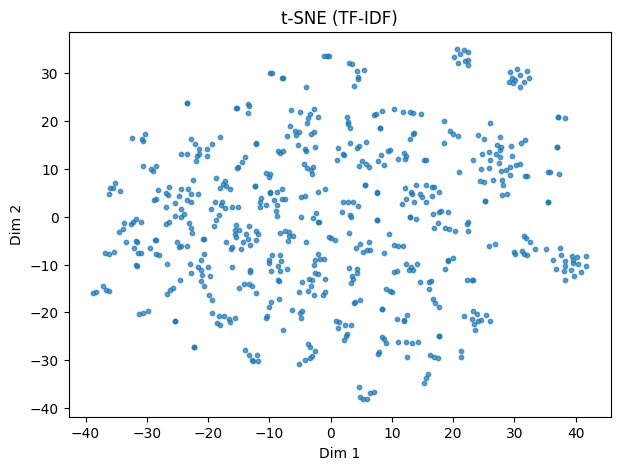

In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne_tfidf = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tfidf_2d = tsne_tfidf.fit_transform(tfidf_embedding.toarray())

plt.figure(figsize=(7, 5))
plt.scatter(tfidf_2d[:, 0], tfidf_2d[:, 1], s=10, alpha=0.7)
plt.title("t-SNE (TF-IDF)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [11]:
tfidf_dense = tfidf_embedding.toarray().astype('float32')

dimension_tfidf = tfidf_dense.shape[1]
index_tfidf = faiss.IndexFlatL2(dimension_tfidf)


index_tfidf.add(tfidf_dense)

print(f"TF-IDF FAISS indexinde toplam vektör sayısı: {index_tfidf.ntotal}")

TF-IDF FAISS indexinde toplam vektör sayısı: 582


### SBERT + FAISS

In [12]:
from sentence_transformers import SentenceTransformer

model_sbert = SentenceTransformer('all-MiniLM-L6-v2') 

W0814 13:06:42.236000 17468 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.



In [13]:
embedding_sbert = model_sbert.encode(all_chunks_en, show_progress_bar=True)

cos_sim_sbert = cosine_similarity(embedding_sbert)

print("SBERT similarity shape:", cos_sim_sbert.shape)

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

C:\Users\Sadık\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


SBERT similarity shape: (582, 582)


c:\Anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


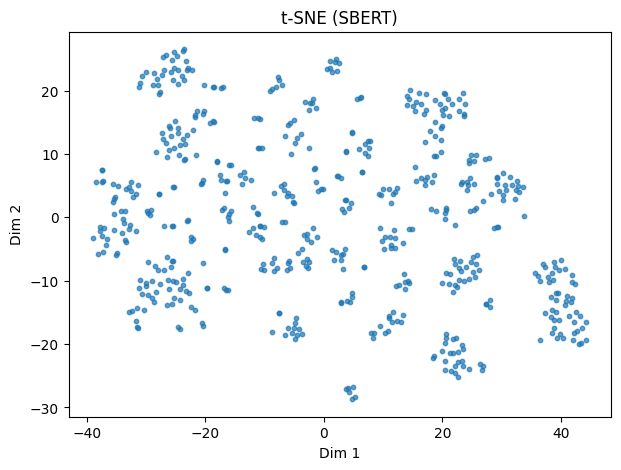

In [14]:
tsne_sbert = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
sbert_2d = tsne_sbert.fit_transform(embedding_sbert)

plt.figure(figsize=(7, 5))
plt.scatter(sbert_2d[:, 0], sbert_2d[:, 1], s=10, alpha=0.7)
plt.title("t-SNE (SBERT)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [15]:
import faiss
import numpy as np

dimension_sbert = embedding_sbert.shape[1]
index_sbert = faiss.IndexFlatL2(dimension_sbert)  # L2 mesafesine göre index
index_sbert.add(np.array(embedding_sbert))  # Vektörleri ekle

### GoogleEmbedding + FAISS

In [16]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
import faiss
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv()

# 1. Google Generative AI embedding nesnesini oluştur
model_google = GoogleGenerativeAIEmbeddings(model= "models/embedding-001")

# 2. all_chunks_en içindeki tüm chunk'ları embed et (dizi halinde)
embedding_google = [model_google.embed_query(chunk) for chunk in all_chunks_en]

# 3. Listeyi numpy array haline getir, FAISS float32 ister
embedding_google_np = np.array(embedding_google).astype('float32')

cos_sim_google = cosine_similarity(embedding_google_np)

print("Google similarity shape:", cos_sim_google.shape)

Google similarity shape: (582, 582)


c:\Anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


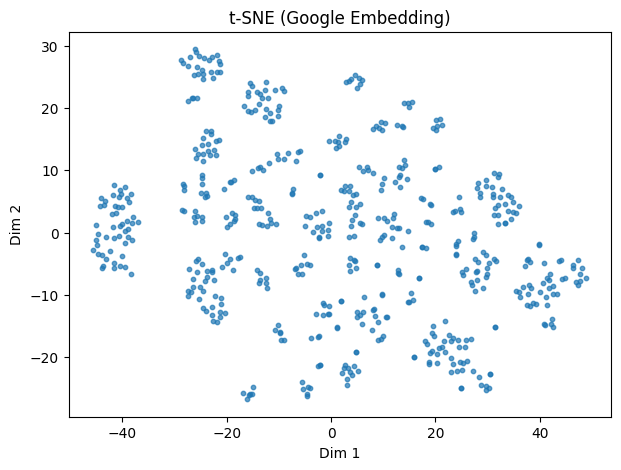

In [17]:
tsne_google = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
google_2d = tsne_google.fit_transform(np.array(embedding_google))

plt.figure(figsize=(7, 5))
plt.scatter(google_2d[:, 0], google_2d[:, 1], s=10, alpha=0.7)
plt.title("t-SNE (Google Embedding)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [18]:
# 4. FAISS index oluştur (dim embedding boyutuna göre)
dimension_google = embedding_google_np.shape[1]
index_google = faiss.IndexFlatL2(dimension_google)

# 5. Vektörleri indexe ekle
index_google.add(embedding_google_np)

### Query for TF-IDF

In [19]:
query = "What is atom?"
query_vec = vectorizer.transform([query]).toarray().astype('float32')

k = 5  # en yakın 5 sonucu getir
distances, indices = index_tfidf.search(query_vec, k)

print(f"En yakın {k} sonuç indeksleri: {indices}")
print(f"Mesafeler: {distances}")

for rank, idx in enumerate(indices[0], 1):
    chunk_text = all_chunks_en[idx]
    first_100_words = ' '.join(chunk_text.split()[:100])
    print(f"\nRank {rank} - Index {idx} - Mesafe {distances[0][rank-1]:.4f}")
    print(first_100_words)

En yakın 5 sonuç indeksleri: [[178 186 177 171 172]]
Mesafeler: [[1.4801813 1.494276  1.5051546 1.5188291 1.5576974]]

Rank 1 - Index 178 - Mesafe 1.4802
actually existed . To prove they were real , physicist James Chadwick and a team of others created the mass spectrometer . The mass spectrometer actually measures the mass and weight of individual atoms . By doing this Chadwick proved that to account for all the weight of the atom , neutrons must exist . In 1937 , German chemist Otto Hahn became the first person to create nuclear fission in a laboratory . He discovered this by chance when he was shooting neutrons at a uranium atom , hoping to create a new isotope . However , he noticed

Rank 2 - Index 186 - Mesafe 1.4943
electron . In the second case it is a positron ( like an electron but with a positive charge ) . The end result is an element with one higher or one lower atomic number than before . Beta decay happens when an atom has either too many protons , or too many neutrons . 

### Query for SBERT

In [20]:
query_text = "What is atom?"

query_embedding = model_sbert.encode(query_text).reshape(1, -1).astype('float32')

k = 5  # En yakın 5 sonucu getir
distances, indices = index_sbert.search(query_embedding, k)

print("Sorgu chunk:", query_text)
print("\nEn yakın chunklar:")
for i, idx in enumerate(indices[0]):
    print(f"Rank {i+1}, mesafe: {distances[0][i]:.4f}, metin: {all_chunks_en[idx][:100]}...")

Sorgu chunk: What is atom?

En yakın chunklar:
Rank 1, mesafe: 0.6154, metin: has 16 protons . Because the mass of neutrons and protons is very similar , and the mass of electron...
Rank 2, mesafe: 0.7099, metin: molecules make up a glass of water . When atoms join together it is called a chemical reaction . Ato...
Rank 3, mesafe: 0.7120, metin: Atoms are very small pieces of matter . There are many different types of atoms , each with its own ...
Rank 4, mesafe: 0.7969, metin: of the atomic bomb . Further into the 20th century , physicists went deeper into the mysteries of th...
Rank 5, mesafe: 0.8677, metin: . For example , any atom with 2 protons should be a helium atom . Usually , a helium nucleus also co...


C:\Users\Sadık\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


### Query for GoogleEmbedding

In [21]:
query = "What is atom?"
query_vec = model_google.embed_query(query)
query_vec = np.array(query_vec).astype('float32').reshape(1, -1)

k = 5
distances, indices = index_google.search(query_vec, k)

print(f"En yakın {k} sonuç indeksleri: {indices}")
print(f"Mesafeler: {distances}")

for rank, idx in enumerate(indices[0], 1):
    chunk_text = all_chunks_en[idx]
    first_100_words = ' '.join(chunk_text.split()[:100])
    print(f"\nRank {rank} - Index {idx} - Mesafe {distances[0][rank-1]:.4f}")
    print(first_100_words)

En yakın 5 sonuç indeksleri: [[170 172 179 171 359]]
Mesafeler: [[0.6101829  0.6299462  0.6918342  0.72029185 0.74670076]]

Rank 1 - Index 170 - Mesafe 0.6102
Atoms are very small pieces of matter . There are many different types of atoms , each with its own name , mass and size . These different types of atoms are called chemical elements . The chemical elements are organized on the periodic table . Examples of elements are hydrogen , carbon , chlorine , and gold etc . Atoms are very small , but their exact size depends on the element . Atoms range from 0.1 to 0.5 nanometers in width . One nanometer is about 100,000 times smaller than the width of a human hair . This

Rank 2 - Index 172 - Mesafe 0.6299
has 16 protons . Because the mass of neutrons and protons is very similar , and the mass of electrons is very small , we can call the amount of protons and neutrons in an atom its atomic mass . Atoms move faster when they are in their gas form ( because they are free to move ) than they

### Cosine Similarity

#### TF-IDF

In [22]:
faiss.normalize_L2(tfidf_dense)

# 4. FAISS index oluştur (inner product -> cosine similarity)
dimension_tfidf = tfidf_dense.shape[1]
index_tfidf = faiss.IndexFlatIP(dimension_tfidf)

# 5. Vektörleri indexe ekle
index_tfidf.add(tfidf_dense)

print(f"TF-IDF FAISS indexinde toplam vektör sayısı: {index_tfidf.ntotal}")

TF-IDF FAISS indexinde toplam vektör sayısı: 582


In [23]:
query = "What is atom?"

# 1. TF-IDF vektörünü çıkar
query_vec = vectorizer.transform([query]).toarray().astype('float32')

# 2. Normalize et
faiss.normalize_L2(query_vec)

# 3. Arama yap
k = 5
scores, indices = index_tfidf.search(query_vec, k)

print(f"En yakın {k} sonuç indeksleri: {indices}")
print(f"Benzerlik skorları (Cosine similarity): {scores}")

for rank, idx in enumerate(indices[0], 1):
    chunk_text = all_chunks_en[idx]
    first_100_words = ' '.join(chunk_text.split()[:100])
    print(f"\nRank {rank} - Index {idx} - Skor {scores[0][rank-1]:.4f}")
    print(first_100_words)

En yakın 5 sonuç indeksleri: [[178 186 177 171 172]]
Benzerlik skorları (Cosine similarity): [[0.25990933 0.25286198 0.24742267 0.24058545 0.22115132]]

Rank 1 - Index 178 - Skor 0.2599
actually existed . To prove they were real , physicist James Chadwick and a team of others created the mass spectrometer . The mass spectrometer actually measures the mass and weight of individual atoms . By doing this Chadwick proved that to account for all the weight of the atom , neutrons must exist . In 1937 , German chemist Otto Hahn became the first person to create nuclear fission in a laboratory . He discovered this by chance when he was shooting neutrons at a uranium atom , hoping to create a new isotope . However , he noticed

Rank 2 - Index 186 - Skor 0.2529
electron . In the second case it is a positron ( like an electron but with a positive charge ) . The end result is an element with one higher or one lower atomic number than before . Beta decay happens when an atom has either too many pro

#### SBERT

In [24]:
faiss.normalize_L2(embedding_sbert)

dimension_sbert = embedding_sbert.shape[1]

index_sbert = faiss.IndexFlatIP(dimension_sbert)

index_sbert.add(embedding_sbert)

print(f"SBERT FAISS indexinde toplam vektör sayısı: {index_sbert.ntotal}")

SBERT FAISS indexinde toplam vektör sayısı: 582


In [25]:
query = "What is atom?"

query_vec = model_sbert.encode([query])
query_vec = np.array(query_vec).astype('float32')

faiss.normalize_L2(query_vec)

k = 5
scores, indices = index_sbert.search(query_vec, k)

print(f"En yakın {k} sonuç indeksleri: {indices}")
print(f"Benzerlik skorları (Cosine similarity): {scores}")

for rank, idx in enumerate(indices[0], 1):
    chunk_text = all_chunks_en[idx]
    first_100_words = ' '.join(chunk_text.split()[:100])
    print(f"\nRank {rank} - Index {idx} - Skor {scores[0][rank-1]:.4f}")
    print(first_100_words)


En yakın 5 sonuç indeksleri: [[172 171 170 179 177]]
Benzerlik skorları (Cosine similarity): [[0.6923157  0.64505595 0.64397967 0.6015396  0.566126  ]]

Rank 1 - Index 172 - Skor 0.6923
has 16 protons . Because the mass of neutrons and protons is very similar , and the mass of electrons is very small , we can call the amount of protons and neutrons in an atom its atomic mass . Atoms move faster when they are in their gas form ( because they are free to move ) than they do in liquid form and solid matter . In solid materials , the atoms are tightly packed next to each other so they vibrate , but are not able to move ( there is no room ) as atoms in

Rank 2 - Index 171 - Skor 0.6451
molecules make up a glass of water . When atoms join together it is called a chemical reaction . Atoms can join together without forming separate molecules , in this case every atom is connected to a giant web of atoms , these are called crystals . Atoms are made up of three kinds of smaller particles , calle

#### Google Embedding

In [26]:
faiss.normalize_L2(embedding_google_np)

# 4. FAISS index oluştur, inner product kullan (cosine similarity için)
dimension = embedding_google_np.shape[1]
index_google = faiss.IndexFlatIP(dimension)

# 5. Normalize edilmiş vektörleri indexe ekle
index_google.add(embedding_google_np)


In [27]:
query = "What is atom?"
query_vec = model_google.embed_query(query)
query_vec = np.array(query_vec).astype('float32').reshape(1, -1)

faiss.normalize_L2(query_vec)

k = 5

scores, indices = index_google.search(query_vec, k)

print(f"En yakın {k} sonuç indeksleri: {indices}")
print(f"Benzerlik skorları (Cosine similarity): {scores}")

for rank, idx in enumerate(indices[0], 1):
    chunk_text = all_chunks_en[idx]
    first_100_words = ' '.join(chunk_text.split()[:100])
    print(f"\nRank {rank} - Index {idx} - Benzerlik skoru {scores[0][rank-1]:.4f}")
    print(first_100_words)

En yakın 5 sonuç indeksleri: [[170 172 179 171 359]]
Benzerlik skorları (Cosine similarity): [[0.69490695 0.6850252  0.6540811  0.6398522  0.6266477 ]]

Rank 1 - Index 170 - Benzerlik skoru 0.6949
Atoms are very small pieces of matter . There are many different types of atoms , each with its own name , mass and size . These different types of atoms are called chemical elements . The chemical elements are organized on the periodic table . Examples of elements are hydrogen , carbon , chlorine , and gold etc . Atoms are very small , but their exact size depends on the element . Atoms range from 0.1 to 0.5 nanometers in width . One nanometer is about 100,000 times smaller than the width of a human hair . This

Rank 2 - Index 172 - Benzerlik skoru 0.6850
has 16 protons . Because the mass of neutrons and protons is very similar , and the mass of electrons is very small , we can call the amount of protons and neutrons in an atom its atomic mass . Atoms move faster when they are in their gas f